In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import cartopy
import cartopy.crs as ccrs

## Programming Assignment 10:

This assignment will be submitted as a link to a jupyter notebook.

#### Read in the following two Data Sets

In [2]:
website = 'https://joannabieri.com/python/'
file_name = website + 'states.geojson'

statesDF = gpd.read_file(file_name)
display(statesDF.head(5))

'''
Notes on the Column Names
IPR_EST Income-to-poverty ratio, estimate Numeric 3
IPR_SE Income-to-poverty ratio, standard error Numeric 3
'''

website = 'https://joannabieri.com/python/'
file_name = website + 'School_Neighborhood_Poverty_Estimates_-_Current.geojson'
povertyDF = gpd.read_file(file_name)
display(povertyDF.head(5))


,OBJECTID,NAME,geometry
0,1,Texas,"POLYGON ((-106.62345 31.91403, -106.63012 31.9..."
1,2,California,"MULTIPOLYGON (((-118.59453 33.46713, -118.4853..."
2,3,Kentucky,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
3,4,Georgia,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
4,5,Wisconsin,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."


,OBJECTID,NAME,NCESSCH,IPR_EST,IPR_SE,SCHOOLYEAR,LAT,LON,geometry
0,1,Albertville Middle School,010000500870,259,87,2020-2021,34.2602,-86.206200,POINT (-86.2062 34.26021)
1,2,Albertville High School,010000500871,261,92,2020-2021,34.2622,-86.204900,POINT (-86.2049 34.26221)
2,3,Albertville Intermediate School,010000500879,139,61,2020-2021,34.2733,-86.220100,POINT (-86.2201 34.27331)
3,4,Albertville Elementary School,010000500889,227,110,2020-2021,34.2527,-86.221806,POINT (-86.22181 34.25271)
4,5,Albertville Kindergarten and PreK,010000501616,373,124,2020-2021,34.2898,-86.193300,POINT (-86.1933 34.28981)


## 1. Get information about each of the data frames

1. What are the column names?
2. How many rows are there?
3. What is the info() - what data types are there?
4. What are the basic statistics?

## 2. Plot the data

1. Make a spatial plot of the state data - this should be a map of the USA with colors corresponding to the different states. (plot the NAME column with no legend)

2. Make a spatial plot of the poverty data (specifically the 'IPR_EST' column) - this should be a map with dots on it representing each of the schools

## 3. Lets focus on data for just one state that you are interested in

1. Join the data sets so that the state data is in the same data frame as the poverty data. 
    - remember to make sure they are using the same projection .to_crs(crs=ccrs.PlateCarree())
    - use the povertyDF as the LEFT dataframe and the statesDF as the RIGHT dataframe
    - save the joined data in a new variable  joinDF = povertyDF.sjoin(statesDF)
    
2. Choose a state and mask the joinDF so it only includes data from your state.

3. Plot the "IPR_EST" just for your state

In [ ]:
# Here is some example plotting code that you can use if you want to add the state boundaries to your map
# The data frame my_stateDF contains the information just for the state I am interested in
# state = 'Idaho' was the variable I used to choose a state.

fig = plt.figure(figsize=(12, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the dots for the IPR_EST
my_stateDF.plot(ax=ax,
         column='IPR_EST',
         markersize=my_stateDF['IPR_EST']/10,
         legend=True)

# Plot the outline useing the geometry from the state data
statesDF[statesDF['NAME']==state]['geometry'].plot(facecolor="none",
                                       edgecolor='black',
                                       ax=ax)

## 4. For the state you are interested in:

1. What are the top 10 highest poverty schools on your states list?
2. What is the average IPR_EST for your state?
3. How does your state compare to the average IPR_EST of other states? You might need to loop through the other states to see what their averages are. You might want to write a function for this.

## Challenge:

Go to the government database website and find some data you are interested in:

https://catalog.data.gov/dataset/?metadata_type=geospatial&_res_format_limit=0&res_format=GeoJSON

Analyze your data and create some maps using geopandas.

In [3]:
#1 
print(statesDF.columns)
print(povertyDF.columns)

Index(['OBJECTID', 'NAME', 'geometry'], dtype='object')
Index(['OBJECTID', 'NAME', 'NCESSCH', 'IPR_EST', 'IPR_SE', 'SCHOOLYEAR', 'LAT',
       'LON', 'geometry'],
      dtype='object')


In [5]:
#1
print(statesDF.shape)
print(povertyDF.shape)

(52, 3)
(100682, 9)


In [6]:
#1 
statesDF.info()
povertyDF.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   OBJECTID  52 non-null     int32   
 1   NAME      52 non-null     object  
 2   geometry  51 non-null     geometry
dtypes: geometry(1), int32(1), object(1)
memory usage: 1.1+ KB
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 100682 entries, 0 to 100681
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   OBJECTID    100682 non-null  int32   
 1   NAME        100682 non-null  object  
 2   NCESSCH     100682 non-null  object  
 3   IPR_EST     100682 non-null  int32   
 4   IPR_SE      100682 non-null  int32   
 5   SCHOOLYEAR  100682 non-null  object  
 6   LAT         100682 non-null  float64 
 7   LON         100682 non-null  float64 
 8   geometry    100682 non-null  geometry
dtypes: float64(2), geometry(1), int

In [7]:
#1
statesDF.describe()
povertyDF.describe()

,OBJECTID,IPR_EST,IPR_SE,LAT,LON
count,100682.000000,100682.000000,100682.000000,100682.000000,100682.000000
mean,50341.500000,319.768529,79.257186,38.029483,-93.389631
std,29064.534238,159.597605,40.484459,5.358186,16.036053
min,1.000000,24.000000,2.000000,19.061158,-176.640331
25%,25171.250000,212.000000,49.000000,34.012126,-102.084069
50%,50341.500000,279.000000,71.000000,38.804400,-89.707447
75%,75511.750000,382.000000,102.000000,41.692172,-81.437475
max,100682.000000,993.000000,346.000000,71.300337,-66.988564


 Question 1:
 The states data frame has 52 rows and 3 columns and represents state boundaries. The poverty data frame has 100,682 rows and 9 columns and has detailed school data with locations and poverty measures. The summary statitics show that there is a wide varitey in poverty estimates across the U.S.

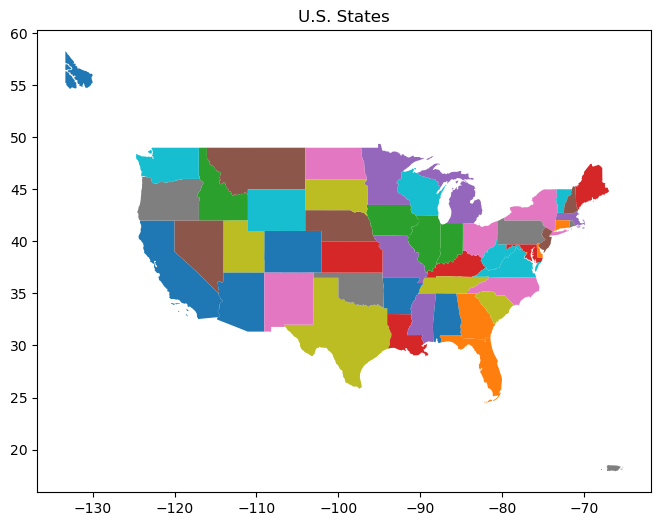

In [11]:
#2
statesDF.plot(column='NAME', legend=False, figsize=(10,6))
plt.title("U.S. States")
plt.show()

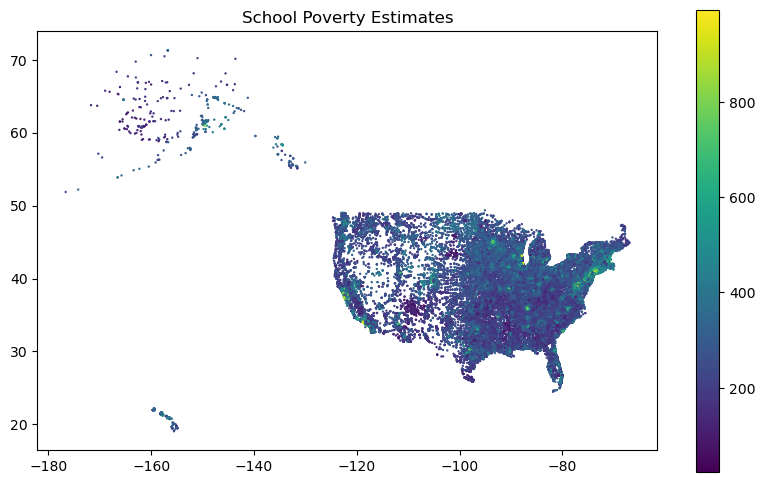

In [21]:
#2
povertyDF.plot(column='IPR_EST',markersize=.5,
               figsize=(10,6),
               legend=True)

plt.title("School Poverty Estimates")
plt.show()

<Axes: >

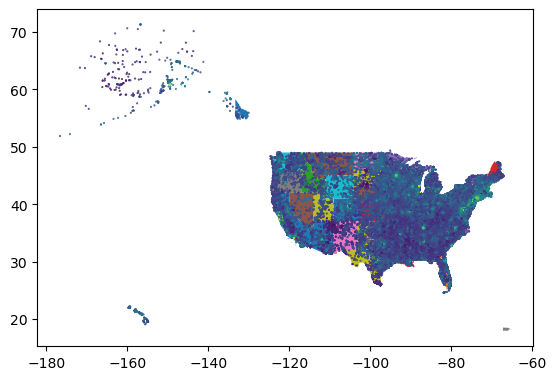

In [23]:
#2
ax = statesDF.plot(column='NAME', legend=False)
povertyDF.plot(ax=ax, column='IPR_EST', markersize=.25)

In [24]:
#3
statesDF = statesDF.to_crs(epsg=4326)
povertyDF = povertyDF.to_crs(epsg=4326)

In [26]:
#3
joinDF = povertyDF.sjoin(statesDF)
stateDF = joinDF[joinDF['NAME_right'] == 'Colorado']

<Axes: >

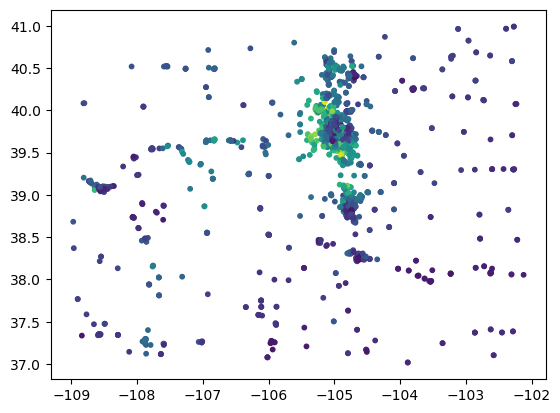

In [28]:
#3
stateDF.plot(column='IPR_EST', markersize=10)

<Axes: >

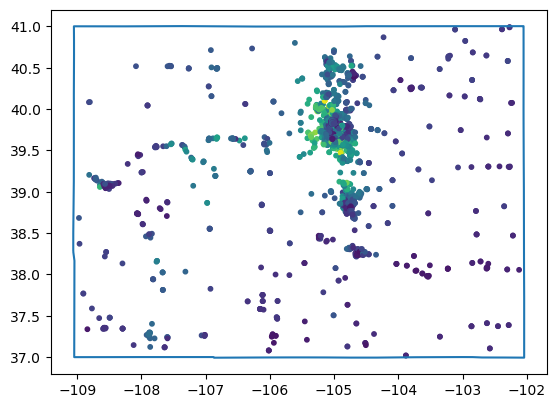

In [30]:
#3
state_shape = statesDF[statesDF['NAME'] == 'Colorado']

ax = state_shape.boundary.plot()

stateDF.plot(ax=ax, column='IPR_EST', markersize=10)

In [35]:
#4
top10_poverty = stateDF.sort_values(by='IPR_EST', ascending=True).head(10)
print(top10_poverty[['NAME_left', 'IPR_EST']])

                                           NAME_left  IPR_EST
17258                       Irving Elementary School      104
17251                            Central High School      110
16162                     Fairview Elementary School      112
17259     Risley International Academy of Innovation      117
16177                        Knapp Elementary School      119
17248                     Bradford Elementary School      119
17271                    Pueblo Youth Service Center      121
17261                     Minnequa Elementary School      121
17246                     Bessemer Elementary School      121
17269  Pueblo Charter School for the Arts & Sciences      125


In [36]:
#4
co_avg = stateDF['IPR_EST'].mean()
print(co_avg)

358.5525231719876


In [37]:
#4
state_avgs = {}

for state in joinDF['NAME_right'].unique():
    temp = joinDF[joinDF['NAME_right'] == state]
    state_avgs[state] = temp['IPR_EST'].mean()

print(state_avgs)

{'Alabama': np.float64(255.76711452335252), 'Arizona': np.float64(281.52985074626866), 'Nevada': np.float64(279.9124183006536), 'Arkansas': np.float64(243.0116696588869), 'California': np.float64(357.2982607860094), 'Colorado': np.float64(358.5525231719876), 'Connecticut': np.float64(440.02882703777334), 'Delaware': np.float64(341.0), 'Maryland': np.float64(428.67345505617976), 'District of Columbia': np.float64(438.7615062761506), 'Florida': np.float64(278.20962517353075), 'Georgia': np.float64(293.2512931034483), 'Idaho': np.float64(262.2134831460674), 'Illinois': np.float64(341.3371194911404), 'Indiana': np.float64(283.27596899224807), 'Kentucky': np.float64(257.34553628773284), 'Ohio': np.float64(297.0882928192232), 'Iowa': np.float64(314.02792452830187), 'Nebraska': np.float64(292.73333333333335), 'Kansas': np.float64(293.15261958997723), 'West Virginia': np.float64(251.18281036834924), 'Louisiana': np.float64(251.63629790310918), 'Mississippi': np.float64(216.74087932647333), 'Ma

In [38]:
#4
print("Colorado avg:", state_avgs['Colorado'])
print("Overall avg:", sum(state_avgs.values())/len(state_avgs))

Colorado avg: 358.5525231719876
Overall avg: 315.550397643139


Question 4:
The top 10 highest poverty schools in Colorado are Irving Elementary (104) and Central High School (110) for the income to poverity ratio estimates. This is a measure of a housholds income and how it compares to the fedaeral poverty levels. These schools have incomes well below the poverty line based on their low IPR estimates. The average IPR estimate in Colorado is about 359 which is higherthan the overall U.S. average of 316. 